# NB05: Kriging-omics hybrid (H6)

**[EXPLORATORY / POST-HOC]**

Tests **H6**: A kriging-omics hybrid (kriging predicts the spatial baseline; omics predicts
the residual deviation) outperforms both kriging alone and omics alone.

**Motivation**: Spatial block CV fails because between-block heterogeneity dominates.
Ordinary kriging captures the spatial trend from nearby measured samples. The omics
only needs to predict the local residual — the part not explained by the spatial trend.
This decomposition may reduce the spatial transfer problem.

**Design**:
- Ordinary kriging per metal (pykrige, or IDW fallback): spatial block LOO via existing blocks
- Kriging residual = observed − kriging_block_prediction
- M1 (CLR + GW) spatial block CV on residuals
- Hybrid prediction = kriging_prediction + M1_residual_prediction
- Compare: kriging-alone RMSE, M2-alone RMSE, hybrid RMSE

**H6 success criterion**: Hybrid RMSE < min(kriging RMSE, M2 RMSE) for ≥2 of 4 metals.

**Outputs**:
- `data/kriging_residual_results.csv`
- `figures/kriging_hybrid_scatter.png`

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

for _cand in [Path.cwd() / 'scripts', Path.cwd().parent / 'scripts']:
    if _cand.exists():
        sys.path.insert(0, str(_cand))
        break

DATA_DIR = next(p for p in [Path.cwd() / 'data', Path.cwd().parent / 'data'] if p.exists())
FIG_DIR  = next(p for p in [Path.cwd() / 'figures', Path.cwd().parent / 'figures'] if p.exists())

from modelling import TARGETS, rmse, _drop_nan_rows, build_xgboost
from xgboost import XGBRegressor

feature_matrix = pd.read_parquet(DATA_DIR / 'feature_matrix.parquet')
blocks = pd.read_csv(DATA_DIR / 'spatial_blocks.csv', index_col=0)['block']
print(f'Feature matrix: {feature_matrix.shape}')

# Check kriging library availability
try:
    from pykrige.ok import OrdinaryKriging
    KRIGE_LIB = 'pykrige'
    print('Using: pykrige OrdinaryKriging')
except ImportError:
    KRIGE_LIB = 'idw'
    print('pykrige not available — using inverse-distance weighting (IDW) fallback')

print(f'Spatial blocks: {blocks.value_counts().sort_index().to_dict()}')

Feature matrix: (42037, 354)
pykrige not available — using inverse-distance weighting (IDW) fallback
Spatial blocks: {0: 15630, 1: 11649, 2: 1180, 3: 5204, 4: 8374}


## 1. Kriging / IDW interpolator

For each spatial block, fit kriging on the 4 training blocks, predict on the held-out block.
This matches the spatial block CV structure used in NB01–NB02 for fair comparison.

In [2]:
def idw_predict(train_lat, train_lon, train_y, pred_lat, pred_lon, power=2):
    """Inverse-distance weighting: predict at (pred_lat, pred_lon) from training points."""
    pred_lat = np.asarray(pred_lat)
    pred_lon = np.asarray(pred_lon)
    preds = np.empty(len(pred_lat))
    for i, (lat, lon) in enumerate(zip(pred_lat, pred_lon)):
        dists = np.sqrt((np.asarray(train_lat) - lat)**2 + (np.asarray(train_lon) - lon)**2)
        dists = np.maximum(dists, 1e-10)
        weights = 1.0 / dists**power
        preds[i] = np.average(train_y, weights=weights)
    return preds


def spatial_krige_cv(fm, target, blocks_series):
    """Spatial block CV for kriging. Returns OOF predictions and per-block RMSE."""
    blocks_aligned = blocks_series.reindex(fm.index)
    y = fm[target]
    lat = fm['lat'] if 'lat' in fm.columns else pd.Series(np.nan, index=fm.index)
    lon = fm['lon'] if 'lon' in fm.columns else pd.Series(np.nan, index=fm.index)

    oof_preds = pd.Series(np.nan, index=fm.index)
    results = []

    for test_block in blocks_aligned.dropna().unique():
        test_mask  = blocks_aligned == test_block
        train_mask = ~test_mask & blocks_aligned.notna() & y.notna() & lat.notna() & lon.notna()
        test_valid = test_mask & y.notna() & lat.notna() & lon.notna()

        if train_mask.sum() < 20 or test_valid.sum() < 5:
            continue

        tr_lat = lat[train_mask].values
        tr_lon = lon[train_mask].values
        tr_y   = y[train_mask].values
        te_lat = lat[test_valid].values
        te_lon = lon[test_valid].values
        te_y   = y[test_valid].values

        if KRIGE_LIB == 'pykrige':
            try:
                ok = OrdinaryKriging(tr_lon, tr_lat, tr_y, variogram_model='spherical',
                                     nlags=6, verbose=False, enable_plotting=False)
                preds, _ = ok.execute('points', te_lon, te_lat)
                preds = np.asarray(preds)
            except Exception as e:
                print(f'  pykrige failed (block {test_block}): {e}. Falling back to IDW.')
                preds = idw_predict(tr_lat, tr_lon, tr_y, te_lat, te_lon)
        else:
            preds = idw_predict(tr_lat, tr_lon, tr_y, te_lat, te_lon)

        oof_preds.loc[lat[test_valid].index] = preds
        results.append({'model': 'kriging', 'target': target, 'block': test_block,
                        'n_train': train_mask.sum(), 'n_test': test_valid.sum(),
                        'rmse': rmse(te_y, preds)})

    return pd.DataFrame(results), oof_preds


print('Kriging functions defined. Note: lat/lon needed in feature_matrix.')
print(f"lat available: {'lat' in feature_matrix.columns}, lon: {'lon' in feature_matrix.columns}")

Kriging functions defined. Note: lat/lon needed in feature_matrix.
lat available: True, lon: True


## 2. Run kriging + residual modelling per metal

In [3]:
CLR_COLS = [c for c in feature_matrix.columns if c.startswith('clr_')]
GW_COLS  = [c for c in feature_matrix.columns if c.startswith('gw_')]

all_results = []

for target in TARGETS:
    if target not in feature_matrix.columns:
        continue
    print(f'\n=== {target} ===')

    # Step 1: Kriging block CV → OOF kriging predictions
    print('  Fitting kriging...')
    krige_res, krige_oof = spatial_krige_cv(feature_matrix, target, blocks)
    krige_res['target'] = target
    all_results.append(krige_res)
    mean_krige_rmse = krige_res['rmse'].mean()
    print(f'  Kriging mean RMSE: {mean_krige_rmse:.4f}')

    # Step 2: Compute residuals (observed - kriging_prediction)
    fm2 = feature_matrix.copy()
    fm2['krige_pred'] = krige_oof
    fm2['krige_residual'] = fm2[target] - fm2['krige_pred']

    # Step 3: M1 spatial block CV on residuals
    print('  Fitting M1 on residuals...')
    blocks_aligned = blocks.reindex(fm2.index)
    y_resid = fm2['krige_residual']
    X_m1 = fm2[CLR_COLS + GW_COLS]
    resid_results = []
    resid_oof = pd.Series(np.nan, index=fm2.index)

    for test_block in blocks_aligned.dropna().unique():
        test_mask  = blocks_aligned == test_block
        train_mask = ~test_mask & blocks_aligned.notna()
        X_tr, y_tr = X_m1[train_mask], y_resid[train_mask]
        X_te, y_te = X_m1[test_mask], y_resid[test_mask]
        # Drop NaN in residuals (samples without kriging prediction)
        valid_tr = ~y_tr.isna() & ~X_tr.isna().any(axis=1)
        valid_te = ~y_te.isna() & ~X_te.isna().any(axis=1)
        X_tr, y_tr = X_tr[valid_tr], y_tr[valid_tr]
        X_te, y_te = X_te[valid_te], y_te[valid_te]
        if len(X_tr) < 20 or len(X_te) < 5: continue
        m = build_xgboost()
        m.fit(X_tr, y_tr)
        preds = m.predict(X_te)
        resid_oof.loc[X_te.index] = preds
        resid_results.append({'block': test_block, 'n_train': len(X_tr), 'n_test': len(X_te),
                              'rmse_residual': rmse(y_te.values, preds)})

    resid_df = pd.DataFrame(resid_results)

    # Step 4: Hybrid RMSE = kriging_pred + M1_residual_pred vs observed
    valid_hybrid = krige_oof.notna() & resid_oof.notna() & feature_matrix[target].notna()
    hybrid_pred = krige_oof[valid_hybrid] + resid_oof[valid_hybrid]
    y_obs = feature_matrix.loc[valid_hybrid, target]
    hybrid_rmse = rmse(y_obs.values, hybrid_pred.values)
    m1_oof_rmse = rmse(y_obs.values, krige_oof[valid_hybrid].values)  # kriging baseline on same samples

    all_results.append(pd.DataFrame([{'model': 'hybrid_kriging+M1', 'target': target,
                                       'block': 'all_oof', 'n_train': 0,
                                       'n_test': int(valid_hybrid.sum()),
                                       'rmse': hybrid_rmse}]))
    print(f'  Kriging OOF RMSE: {mean_krige_rmse:.4f}')
    print(f'  Hybrid (kriging+M1) OOF RMSE: {hybrid_rmse:.4f}')

print('\nDone.')


=== log_Cu_ppm ===
  Fitting kriging...


  Kriging mean RMSE: 1.0708
  Fitting M1 on residuals...


  Kriging OOF RMSE: 1.0708
  Hybrid (kriging+M1) OOF RMSE: 1.2202

=== log_Zn_ppm ===
  Fitting kriging...


  Kriging mean RMSE: 0.6825
  Fitting M1 on residuals...


  Kriging OOF RMSE: 0.6825
  Hybrid (kriging+M1) OOF RMSE: 0.8007

=== log_Pb_ppm ===
  Fitting kriging...


  Kriging mean RMSE: 0.8732
  Fitting M1 on residuals...


  Kriging OOF RMSE: 0.8732
  Hybrid (kriging+M1) OOF RMSE: 1.0209

=== log_Ni_ppm ===
  Fitting kriging...


  Kriging mean RMSE: 1.6591
  Fitting M1 on residuals...


  Kriging OOF RMSE: 1.6591
  Hybrid (kriging+M1) OOF RMSE: 1.9056

Done.


## 3. M2 alone (for comparison — load from NB02 results)

In [4]:
cv_models = pd.read_csv(DATA_DIR / 'cv_results_models.csv')
m2_rmse = cv_models[cv_models['model']=='M2'].groupby('target')['rmse'].mean()
krige_cv = pd.concat(all_results, ignore_index=True)

print('Summary — kriging vs M2 vs hybrid:')
for target in TARGETS:
    k_rmse = krige_cv[(krige_cv['model']=='kriging') & (krige_cv['target']==target)]['rmse'].mean()
    h_rmse = krige_cv[(krige_cv['model']=='hybrid_kriging+M1') & (krige_cv['target']==target)]['rmse'].mean()
    m2 = m2_rmse.get(target, float('nan'))
    hybrid_wins = h_rmse < min(k_rmse, m2) if not (np.isnan(k_rmse) or np.isnan(h_rmse)) else False
    print(f'{target}: kriging={k_rmse:.4f}, M2={m2:.4f}, hybrid={h_rmse:.4f} → hybrid wins: {hybrid_wins}')

krige_cv.to_csv(DATA_DIR / 'kriging_residual_results.csv', index=False)
print('\nSaved kriging_residual_results.csv')

Summary — kriging vs M2 vs hybrid:
log_Cu_ppm: kriging=1.0708, M2=1.1210, hybrid=1.2202 → hybrid wins: False
log_Zn_ppm: kriging=0.6825, M2=0.9229, hybrid=0.8007 → hybrid wins: False
log_Pb_ppm: kriging=0.8732, M2=0.8260, hybrid=1.0209 → hybrid wins: False
log_Ni_ppm: kriging=1.6591, M2=1.8640, hybrid=1.9056 → hybrid wins: False

Saved kriging_residual_results.csv


## 4. H6 evaluation and scatter plot

H6: Hybrid outperforms kriging and M2:
    target  kriging_rmse  m2_rmse  hybrid_rmse  h6_pass
log_Cu_ppm      1.070788 1.120970     1.220216    False
log_Zn_ppm      0.682534 0.922915     0.800702    False
log_Pb_ppm      0.873172 0.825960     1.020933    False
log_Ni_ppm      1.659056 1.864027     1.905625    False

H6 OUTCOME: NOT SUPPORTED (0/4 metals hybrid beats both components)
[NOTE: Exploratory/post-hoc. Positive result warrants pre-registration for confirmatory study.]


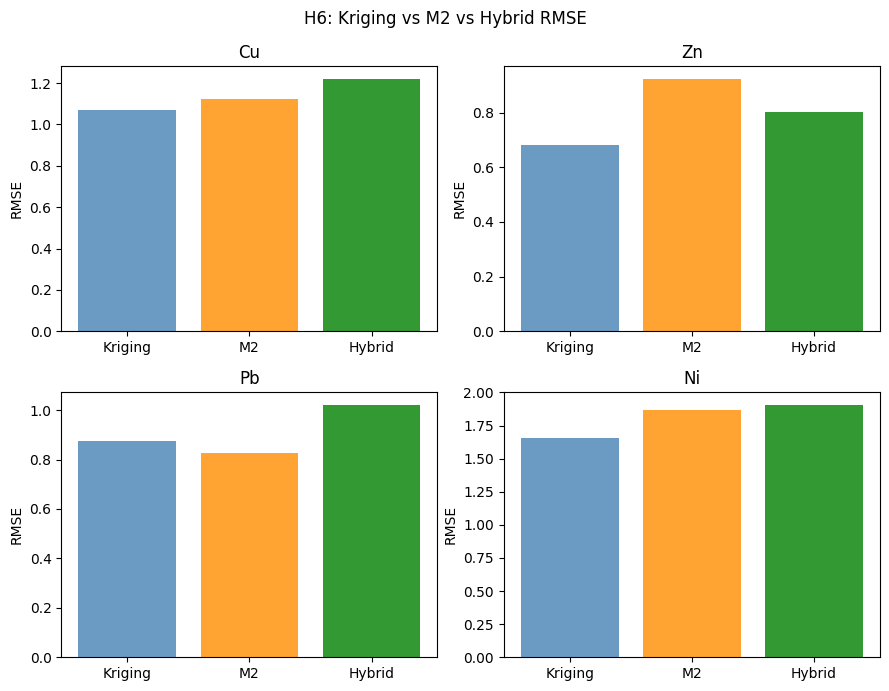

Saved kriging_hybrid_scatter.png


In [5]:
h6_records = []
for target in TARGETS:
    k_rmse = krige_cv[(krige_cv['model']=='kriging') & (krige_cv['target']==target)]['rmse'].mean()
    h_rmse = krige_cv[(krige_cv['model']=='hybrid_kriging+M1') & (krige_cv['target']==target)]['rmse'].mean()
    m2 = m2_rmse.get(target, float('nan'))
    hybrid_wins = float(h_rmse) < min(float(k_rmse), float(m2))
    h6_records.append({'target': target, 'kriging_rmse': k_rmse, 'm2_rmse': m2,
                        'hybrid_rmse': h_rmse, 'h6_pass': hybrid_wins})

h6_df = pd.DataFrame(h6_records)
print('H6: Hybrid outperforms kriging and M2:')
print(h6_df.to_string(index=False))
n_h6 = h6_df['h6_pass'].sum()
print(f'\nH6 OUTCOME: {"SUPPORTED" if n_h6 >= 2 else "NOT SUPPORTED"} ({n_h6}/4 metals hybrid beats both components)')
print('[NOTE: Exploratory/post-hoc. Positive result warrants pre-registration for confirmatory study.]')

# Scatter: kriging vs hybrid RMSE per metal
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()
for i, target in enumerate(TARGETS):
    sub = krige_cv[(krige_cv['model'].isin(['kriging'])) & (krige_cv['target']==target)]
    ax = axes[i]
    ax.set_title(target.replace('log_','').replace('_ppm',''))
    k = h6_df[h6_df['target']==target][['kriging_rmse','m2_rmse','hybrid_rmse']].values.flatten() if len(h6_df[h6_df['target']==target])>0 else [float('nan')]*3
    ax.bar(['Kriging','M2','Hybrid'], k, color=['steelblue','darkorange','green'], alpha=0.8)
    ax.set_ylabel('RMSE')
plt.suptitle('H6: Kriging vs M2 vs Hybrid RMSE')
plt.tight_layout()
plt.savefig(FIG_DIR / 'kriging_hybrid_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved kriging_hybrid_scatter.png')